In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Set seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_dir = os.path.join("..", "..", "dataset (tasks 2 and 3)")
train_path = os.path.join(data_dir, "train.csv")
test_path = os.path.join(data_dir, "test.csv")

In [46]:
df_train_full = pd.read_csv(train_path)
df_train_full.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


In [47]:
df_train_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   label                   40000 non-null  int64  
 1   integer_feature_1       32604 non-null  float64
 2   integer_feature_2       36524 non-null  float64
 3   integer_feature_3       30183 non-null  float64
 4   integer_feature_4       24005 non-null  float64
 5   integer_feature_5       24587 non-null  float64
 6   integer_feature_6       36473 non-null  float64
 7   integer_feature_7       38787 non-null  float64
 8   integer_feature_8       40000 non-null  int64  
 9   integer_feature_9       40000 non-null  int64  
 10  integer_feature_10      36473 non-null  float64
 11  integer_feature_11      24587 non-null  float64
 12  integer_feature_12      39889 non-null  float64
 13  integer_feature_13      30183 non-null  float64
 14  categorical_feature_1   38379 non-null  str    
 

In [48]:
df_train_full.describe()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,integer_feature_10,integer_feature_11,integer_feature_12,integer_feature_13
count,40000.000000,32604.000000,36524.000000,30183.000000,24005.000000,24587.000000,36473.000000,38787.000000,40000.000000,40000.000000,36473.000000,24587.000000,3.988900e+04,30183.000000
mean,0.032000,35.691326,407.400641,7.116324,146.996626,22.337699,1.606010,0.159950,115.482225,10.040550,0.267074,4.154106,2.183603e+04,8.911440
std,0.176002,545.040254,703.383021,9.264465,625.116575,70.349743,6.210465,1.646236,389.820072,12.351223,0.542083,7.221938,7.756904e+04,14.744663
min,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000
25%,0.000000,3.000000,55.000000,2.000000,9.000000,2.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,6.010000e+02,2.000000
50%,0.000000,8.000000,177.000000,4.000000,32.000000,6.000000,0.000000,0.000000,5.000000,5.000000,0.000000,2.000000,2.786000e+03,4.000000
75%,0.000000,24.000000,471.000000,9.000000,96.000000,17.000000,1.000000,0.000000,53.000000,15.000000,0.000000,4.000000,1.143300e+04,11.000000
max,1.000000,65535.000000,8000.000000,491.000000,42898.000000,2107.000000,288.000000,102.000000,8177.000000,50.000000,7.000000,146.000000,2.068079e+06,539.000000


In [49]:
num_cols = [f"integer_feature_{i}" for i in range(1, 14)]
cat_cols = [f"categorical_feature_{i}" for i in range(1, 27)]
target_col = "label"

In [50]:
# Target distribution
pd.DataFrame({
    'Count': df_train_full[target_col].value_counts(),
    'Percentage (%)': df_train_full[target_col].value_counts(normalize=True) * 100
})

,Count,Percentage (%)
label,,
0,38720,96.8
1,1280,3.2


In [51]:
# Top missing features
missing_df = pd.DataFrame({
    'Missing Count': df_train_full.isnull().sum(),
    'Missing (%)': (df_train_full.isnull().sum() / len(df_train_full)) * 100
})
missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False).head(10)

,Missing Count,Missing (%)
integer_feature_4,15995,39.9875
integer_feature_5,15413,38.5325
integer_feature_11,15413,38.5325
categorical_feature_17,14543,36.3575
categorical_feature_16,14543,36.3575
categorical_feature_23,14543,36.3575
categorical_feature_14,14543,36.3575
integer_feature_3,9817,24.5425
integer_feature_13,9817,24.5425
integer_feature_1,7396,18.4900


In [52]:
skewness = df_train_full[num_cols].skew().sort_values(ascending=False)

print(skewness)

integer_feature_1     108.243149
integer_feature_7      32.370940
integer_feature_4      25.496903
integer_feature_5      11.854152
integer_feature_6      11.575370
integer_feature_13      9.808127
integer_feature_12      8.185806
integer_feature_3       7.565966
integer_feature_8       6.188938
integer_feature_11      6.035890
integer_feature_2       5.078872
integer_feature_10      2.375995
integer_feature_9       1.480668
dtype: float64


From `cardinality_df` we found that the maximum cardinality was 13508 this makes and median cardinality as 2568 so if we use one hot encoding produces a high-dimensional sparse representation. Learnable embeddings were used instead to represent each category as a compact dense vector, substantially reducing the dimensionality of the categorical input while allowing the neural network to learn category representations directly from the CTR prediction task.So we are mapping with  

In [ ]:
# Categorical feature cardinality summary
cardinality_df = pd.DataFrame({
    'Unique Categories': [df_train_full[col].nunique() for col in cat_cols]}, index=cat_cols)
cardinality_df.describe().T


,count,mean,std,min,25%,50%,75%,max
Unique Categories,26.0,3996.307692,4562.235739,3.0,37.5,2568.0,5449.5,13508.0


## Preprocessing Pipeline

- **Stratified 80/20 split:** The validation set is separated from the full training data using a stratified split. The target is highly imbalanced (~97% class 0, ~3% class 1), so stratification keeps the class ratio the same in both sets and avoids severely skewed training or validation portions.

- **Missingness indicators:** EDA showed that around 40% of the values in `integer_feature_4`, `integer_feature_5` and `integer_feature_11` are missing. Before imputing, we flag these values and create 3 new binary features (`_isna`) that record whether each value was originally missing.This helps th model to identify that the original value is miising.

- **Imputation:** Because many features have missing values, dropping those rows would discard too much data. Numerical features are filled with the **training-set median**, and categorical features with the **training-set mode**.

- **Log transformation:** Several numerical features are severely right-skewed, so we apply `log(1 + x - x_min)`. Shifting by the training minimum keeps the values non-negative.

- **Standard scaling:** The numerical features have very different ranges and large variances, so we apply `StandardScaler` (fitted on train only) to bring them to zero mean and unit variance.

- **Rare category threshold:** To reduce the effect of extremely rare categories, we set a minimum frequency of 5. Categories below this threshold are not given their own index.

- **Out-of-vocabulary token:** While building the vocabulary, index 0 is reserved as an `<oov>` token for rare and unseen categories.

In [ ]:
# 1. 80/20 Stratified Split
train_df, val_df = train_test_split(df_train_full,test_size=0.20,random_state=42,stratify=df_train_full[target_col])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = pd.read_csv(test_path)

# 2. Missingness Indicators (Feature Engineering)
high_missing_cols = ['integer_feature_4', 'integer_feature_5', 'integer_feature_11']
for c in high_missing_cols:
    train_df[f'{c}_isna'] = train_df[c].isnull().astype(np.float32)
    val_df[f'{c}_isna'] = val_df[c].isnull().astype(np.float32)
    test_df[f'{c}_isna'] = test_df[c].isnull().astype(np.float32)

indicator_cols = [f'{c}_isna' for c in high_missing_cols]

# 3. Numerical Imputation (Median) & Log1p Transformation
num_medians = {}
num_mins = {}
for c in num_cols:
    med = train_df[c].median()
    num_medians[c] = med
    train_df[c] = train_df[c].fillna(med)
    val_df[c] = val_df[c].fillna(med)
    test_df[c] = test_df[c].fillna(med)
    
    min_val = train_df[c].min()
    num_mins[c] = min_val
    train_df[c] = np.log1p(np.maximum(0, train_df[c] - min_val))
    val_df[c] = np.log1p(np.maximum(0, val_df[c] - min_val))
    test_df[c] = np.log1p(np.maximum(0, test_df[c] - min_val))

# Standardize continuous features
scaler = StandardScaler()
X_train_cont = scaler.fit_transform(train_df[num_cols])
X_val_cont = scaler.transform(val_df[num_cols])
X_test_cont = scaler.transform(test_df[num_cols])

# Combine continuous features with missingness indicator features
X_train_num = np.hstack([X_train_cont, train_df[indicator_cols].values])
X_val_num = np.hstack([X_val_cont, val_df[indicator_cols].values])
X_test_num = np.hstack([X_test_cont, test_df[indicator_cols].values])

# 4. Categorical Imputation (Mode / Most Frequent) & Integer Vocabulary
cat_modes = {}
cat_vocabs = {}
cat_vocab_sizes = []
MIN_FREQ = 5

for c in cat_cols:
    mode_val = train_df[c].mode()[0]
    cat_modes[c] = mode_val
    
    filled_train = train_df[c].fillna(mode_val)
    counts = filled_train.value_counts()
    frequent = counts[counts >= MIN_FREQ].index.tolist()
    
    # Index 0 is reserved for OOV / rare tokens
    vocab = {val: idx + 1 for idx, val in enumerate(frequent)}
    cat_vocabs[c] = vocab
    cat_vocab_sizes.append(len(vocab) + 1)

def encode_cats(df, cols, vocabs, modes):
    encoded = np.zeros((len(df), len(cols)), dtype=np.int64)
    for i, c in enumerate(cols):
        v = vocabs[c]
        m = modes[c]
        series = df[c].fillna(m)
        encoded[:, i] = series.map(lambda x: v.get(x, 0)).values
    return encoded

X_train_cat = encode_cats(train_df, cat_cols, cat_vocabs, cat_modes)
X_val_cat = encode_cats(val_df, cat_cols, cat_vocabs, cat_modes)
X_test_cat = encode_cats(test_df, cat_cols, cat_vocabs, cat_modes)

y_train = train_df[target_col].values.astype(np.float32)
y_val = val_df[target_col].values.astype(np.float32)
y_test = test_df[target_col].values.astype(np.float32)

pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Samples': [len(y_train), len(y_val), len(y_test)],
    'Numerical Feats': [X_train_num.shape[1]] * 3,
    'Categorical Feats': [X_train_cat.shape[1]] * 3
})



,Split,Samples,Numerical Feats,Categorical Feats
0,Train,32000,16,26
1,Validation,8000,16,26
2,Test,10000,16,26


## 3. PyTorch Dataset & DataLoader

In [55]:
class CTRDataset(Dataset):
    def __init__(self, num_feats, cat_feats, labels=None):
        self.num_feats = torch.tensor(num_feats, dtype=torch.float32)
        self.cat_feats = torch.tensor(cat_feats, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32) if labels is not None else None

    def __len__(self):
        return len(self.num_feats)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.num_feats[idx], self.cat_feats[idx], self.labels[idx]
        return self.num_feats[idx], self.cat_feats[idx]

BATCH_SIZE = 512

train_loader = DataLoader(CTRDataset(X_train_num, X_train_cat, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CTRDataset(X_val_num, X_val_cat, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CTRDataset(X_test_num, X_test_cat, y_test), batch_size=BATCH_SIZE, shuffle=False)

## Model Architecture

The model uses a **Vanilla Neural CTR (Embedding + MLP)** architecture.

Each categorical feature is passed through its own embedding layer to convert category IDs into dense vectors. The embedding dimensions are selected using the cardinality-based rule of thumb inspired from https://developers.googleblog.com/introducing-tensorflow-feature-columns/:

$$
d \propto v^{0.25}
$$

where \(v\) is the vocabulary size. In our implementation, we use:

$$
d=\min(50,\max(8,\lfloor4v^{0.25}\rfloor))
$$

This allows higher-cardinality categorical features to use larger embeddings while keeping the dimensions within a practical range.

 The embedding vectors from all categorical features are concatenated with the preprocessed numerical features (including missingness indicators) to form a single combined feature vector.


 The final MLP layer produces a single raw logit for CTR prediction, which is converted to a probability using the sigmoid function during inference.

### Overall Flow

```text
Categorical Features
        ↓
   Embeddings
        ↓
Concatenate Embeddings
        │
        ├──────── Numerical Features
        │          + Missingness Indicators
        ↓
   Combined Vector
        ↓
       MLP 
        ↓
     Output Logit
        ↓
      Sigmoid
        ↓
  Click Probability

In [ ]:
class VanillaNeuralCTR(nn.Module):
    def __init__(self,cat_vocab_sizes,num_numerical,hidden_layers=[256, 128, 64],dropout_rate=0.0,use_batch_norm=False):
        super().__init__()
        
        # Embedding dimension rule: min(50, max(8, v^0.25 * 4))
        self.emb_dims = [min(50, max(8, int(v ** 0.25 * 4))) for v in cat_vocab_sizes]
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=v, embedding_dim=dim, padding_idx=0)
            for v, dim in zip(cat_vocab_sizes, self.emb_dims)
        ])
        
        in_dim = sum(self.emb_dims) + num_numerical
        layers = []
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_list = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        cat_vector = torch.cat(emb_list, dim=1)
        x = torch.cat([x_num, cat_vector], dim=1)
        return self.mlp(x).squeeze(-1)

## 5. Training & Evaluation Pipeline

**Loss function.** The model outputs a raw logit and is trained with `BCEWithLogitsLoss`, which combines the sigmoid and binary cross-entropy in one numerically stable operation. Sigmoid is applied only at inference to get click probabilities. No class weighting is used, so the predicted probabilities stay calibrated to the true ~3% click rate.

**Optimiser.** We use Adam with a learning rate of 1e-3, a batch size of 512 and 8 epochs. Adam's per-parameter adaptive step sizes suit sparse embedding gradients, since rarely seen categories receive larger effective updates.

**Model selection (checkpointing).** After each epoch the model is scored on the validation set. The weights from the epoch with the highest validation ROC-AUC are kept and restored at the end of training. This acts as early stopping without needing a patience hyperparameter.

**Evaluation metrics.** Because only ~3% of impressions are clicks, accuracy is misleading, since predicting "no click" everywhere already gives ~97%. ROC-AUC is the main model-selection metric because it measures ranking quality independently of any threshold. PR-AUC (average precision) is reported alongside it because it is more informative under heavy class imbalance. Log loss measures the quality of the predicted probabilities themselves rather than just their ordering. Accuracy and F1 at the default 0.5 threshold are included for completeness and are expected to be poor. Finally, precision, recall and F1 at a threshold tuned on validation describe the model at a realistic operating point.



In [57]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets = []
    all_preds = []
    
    with torch.no_grad():
        for x_num, x_cat, y in dataloader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            logits = model(x_num, x_cat)
            loss = criterion(logits, y)
            total_loss += loss.item() * len(y)
            
            probs = torch.sigmoid(logits)
            all_preds.extend(probs.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    avg_loss = total_loss / len(all_targets)
    
    auc = roc_auc_score(all_targets, all_preds)
    pr_auc = average_precision_score(all_targets, all_preds)
    ll = log_loss(all_targets, all_preds)
    bin_preds = (all_preds >= 0.5).astype(int)
    acc = accuracy_score(all_targets, bin_preds)
    f1 = f1_score(all_targets, bin_preds, zero_division=0)
    
    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "log_loss": ll,
        "accuracy": acc,
        "f1": f1,
        "targets": all_targets,
        "preds": all_preds
    }

def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, weight_decay=0.0):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
    best_val_auc = 0.0
    best_state = None
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_targets = []
        train_preds = []
        
        for x_num, x_cat, y in train_loader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x_num, x_cat)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(y)
            train_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            train_targets.extend(y.cpu().numpy())
            
        train_loss /= len(train_targets)
        train_auc = roc_auc_score(train_targets, train_preds)
        val_metrics = evaluate_model(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_metrics["auc"])
        
        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return history

## 6. Regularization Experiments (BatchNorm, Dropout, L2)

The embedding tables for the high-cardinality categorical features hold most of the model's parameters (up to [13,508] categories in a single feature), so the network can easily memorise the training set. We therefore compare four configurations that differ only in regularization, while the architecture ([256, 128, 64] hidden units), optimiser, learning rate, epochs and seed are held fixed.

The **baseline** uses no BatchNorm, no dropout and no weight decay, and serves as the reference point. The **BatchNorm** variant adds batch normalisation to stabilise activations and smooth optimisation. The **Dropout & L2** variant uses dropout of 0.2 and weight decay of 1e-4 (without BatchNorm) to reduce co-adaptation between units and shrink large weights. The **full regularization** variant combines BatchNorm, dropout and L2.

**Implementation notes.** BatchNorm is placed after each linear layer and before the ReLU, and dropout follows the ReLU. L2 is applied through Adam's `weight_decay` argument, so it acts on all parameters including the embeddings. Index 0 (`<oov>`) uses `padding_idx=0`, so its embedding is a fixed zero vector. Rare and unseen categories therefore contribute no signal, which is the intended behaviour for values the model has not learned from.

Training and validation curves for all four configurations are shown in Section 9.

In [58]:
experiments = {
    "Baseline (No BN, No Drop, No L2)": {
        "use_batch_norm": False,
        "dropout_rate": 0.0,
        "weight_decay": 0.0
    },
    "With BatchNorm (No Drop, No L2)": {
        "use_batch_norm": True,
        "dropout_rate": 0.0,
        "weight_decay": 0.0
    },
    "With Dropout & L2 (No BN)": {
        "use_batch_norm": False,
        "dropout_rate": 0.2,
        "weight_decay": 1e-4
    },
    "Full Regularization (BN + Drop + L2)": {
        "use_batch_norm": True,
        "dropout_rate": 0.2,
        "weight_decay": 1e-4
    }
}

models = {}
histories = {}
val_records = []
criterion = nn.BCEWithLogitsLoss()

for name, cfg in experiments.items():
    seed_everything(42)
    model = VanillaNeuralCTR(
        cat_vocab_sizes=cat_vocab_sizes,
        num_numerical=X_train_num.shape[1],
        hidden_layers=[256, 128, 64],
        dropout_rate=cfg["dropout_rate"],
        use_batch_norm=cfg["use_batch_norm"]
    ).to(device)
    
    history = train_model(
        model,
        train_loader,
        val_loader,
        epochs=8,
        lr=1e-3,
        weight_decay=cfg["weight_decay"]
    )
    val_metrics = evaluate_model(model, val_loader, criterion, device)
    
    models[name] = model
    histories[name] = history
    
    val_records.append({
        "Configuration": name,
        "Val ROC-AUC": val_metrics["auc"],
        "Val PR-AUC": val_metrics["pr_auc"],
        "Val Log Loss": val_metrics["log_loss"],
        "Val Accuracy": val_metrics["accuracy"],
        "Val F1 (@0.5)": val_metrics["f1"]
    })

## 7. Model Comparison on Validation Set

In [59]:
df_val_comparison = pd.DataFrame(val_records)
df_val_comparison.sort_values(by='Val ROC-AUC', ascending=False).reset_index(drop=True)

,Configuration,Val ROC-AUC,Val PR-AUC,Val Log Loss,Val Accuracy,Val F1 (@0.5)
0,With Dropout & L2 (No BN),0.719508,0.085376,0.131711,0.968,0.0
1,"Baseline (No BN, No Drop, No L2)",0.715329,0.087548,0.132804,0.968,0.0
2,"With BatchNorm (No Drop, No L2)",0.688176,0.073870,0.150831,0.968,0.0
3,Full Regularization (BN + Drop + L2),0.680476,0.076730,0.136602,0.968,0.0


In [60]:
# Select the best performing model on the validation set
best_row = df_val_comparison.loc[df_val_comparison["Val ROC-AUC"].idxmax()]
best_name = best_row["Configuration"]
best_model = models[best_name]

pd.DataFrame({
    'Best Selected Configuration': [best_name],
    'Validation ROC-AUC': [best_row['Val ROC-AUC']],
    'Validation Log Loss': [best_row['Val Log Loss']]
})

,Best Selected Configuration,Validation ROC-AUC,Validation Log Loss
0,With Dropout & L2 (No BN),0.719508,0.131711


## 8. Final Evaluation 


In [61]:
# 1. Tune threshold on Validation Set
val_preds = evaluate_model(best_model, val_loader, criterion, device)["preds"]
thresholds = np.linspace(0.05, 0.50, 46)
f1_scores = [f1_score(y_val, (val_preds >= t).astype(int), zero_division=0) for t in thresholds]
opt_threshold = thresholds[np.argmax(f1_scores)]

# 2. Final Evaluation on test.csv
test_metrics = evaluate_model(best_model, test_loader, criterion, device)
test_targets = test_metrics["targets"]
test_preds = test_metrics["preds"]

test_pred_default = (test_preds >= 0.5).astype(int)
test_pred_opt = (test_preds >= opt_threshold).astype(int)

pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Accuracy (@0.5)",
        "F1-Score (@0.5)",
        f"F1-Score (@{opt_threshold:.2f} optimal)",
        f"Precision (@{opt_threshold:.2f} optimal)",
        f"Recall (@{opt_threshold:.2f} optimal)"
    ],
    "Test Set Score": [
        f"{test_metrics['auc']:.4f}",
        f"{test_metrics['pr_auc']:.4f}",
        f"{test_metrics['log_loss']:.4f}",
        f"{test_metrics['accuracy']:.4f}",
        f"{f1_score(test_targets, test_pred_default, zero_division=0):.4f}",
        f"{f1_score(test_targets, test_pred_opt, zero_division=0):.4f}",
        f"{precision_score(test_targets, test_pred_opt, zero_division=0):.4f}",
        f"{recall_score(test_targets, test_pred_opt, zero_division=0):.4f}"
    ]
})

,Metric,Test Set Score
0,ROC-AUC,0.6788
1,PR-AUC,0.0674
2,Log Loss,0.1415
3,Accuracy (@0.5),0.9665
4,F1-Score (@0.5),0.0000
5,F1-Score (@0.07 optimal),0.1289
6,Precision (@0.07 optimal),0.0829
7,Recall (@0.07 optimal),0.2896


## PLOTS

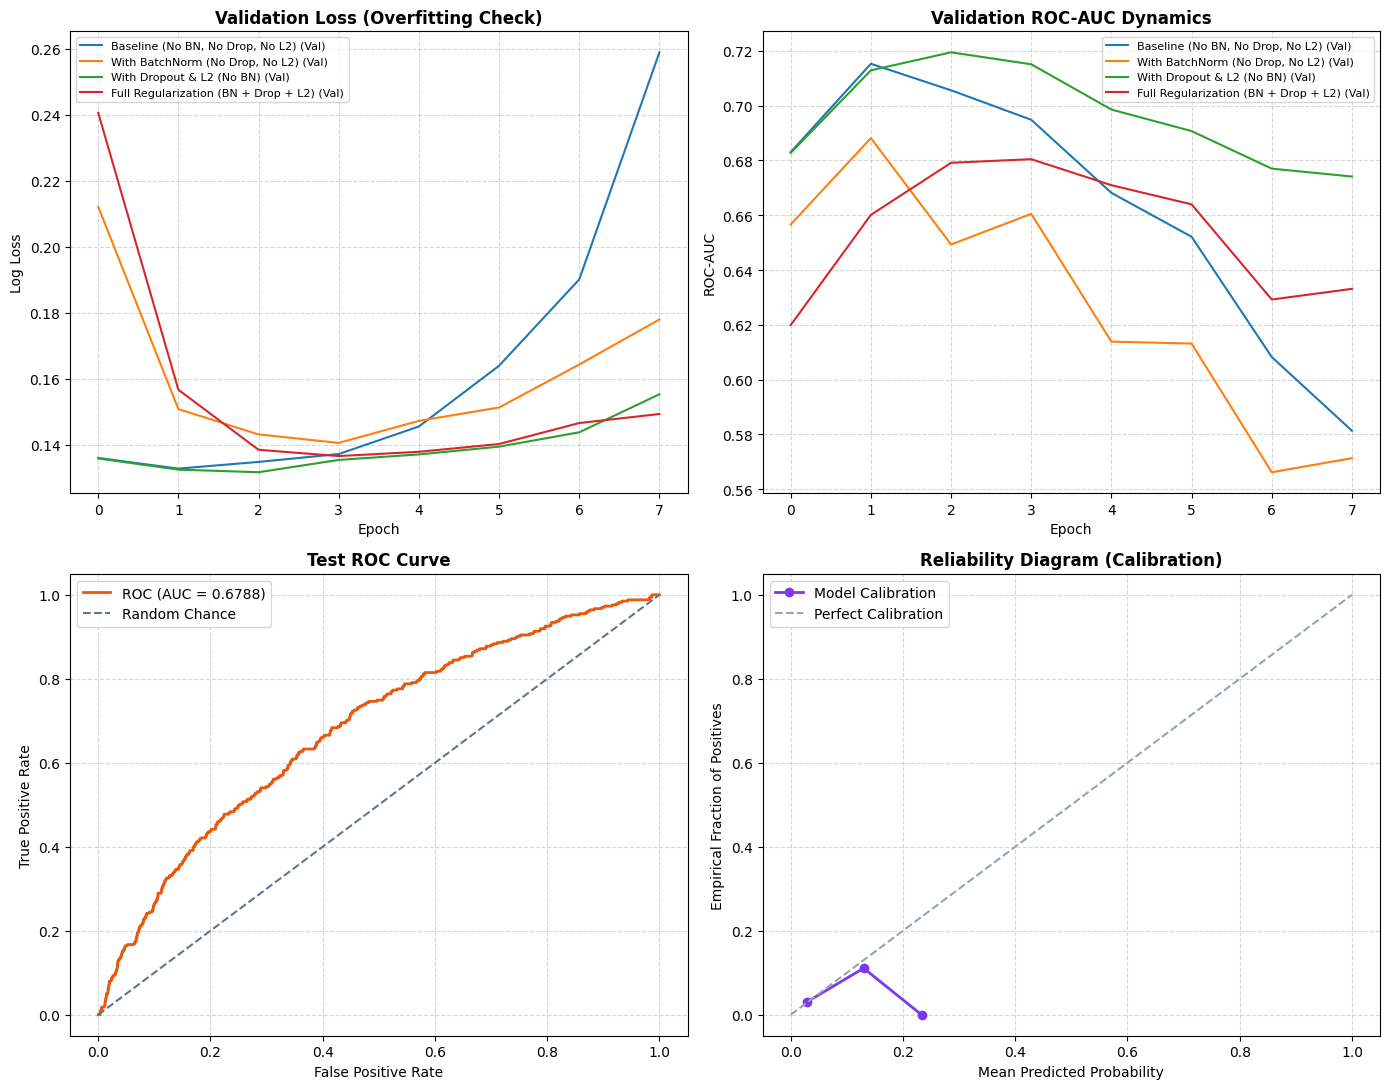

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Loss Curves (Overfitting Inspection)
ax_loss = axes[0, 0]
for name, h in histories.items():
    ax_loss.plot(h["val_loss"], label=f"{name} (Val)")
ax_loss.set_title("Validation Loss (Overfitting Check)", fontweight="bold")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Log Loss")
ax_loss.legend(fontsize=8)
ax_loss.grid(True, linestyle="--", alpha=0.5)

# 2. Validation ROC-AUC Curves
ax_auc = axes[0, 1]
for name, h in histories.items():
    ax_auc.plot(h["val_auc"], label=f"{name} (Val)")
ax_auc.set_title("Validation ROC-AUC Dynamics", fontweight="bold")
ax_auc.set_xlabel("Epoch")
ax_auc.set_ylabel("ROC-AUC")
ax_auc.legend(fontsize=8)
ax_auc.grid(True, linestyle="--", alpha=0.5)

# 3. Test ROC & PR Curves
ax_roc = axes[1, 0]
fpr, tpr, _ = roc_curve(test_targets, test_preds)
ax_roc.plot(fpr, tpr, color="#ea580c", lw=2, label=f"ROC (AUC = {test_metrics['auc']:.4f})")
ax_roc.plot([0, 1], [0, 1], color="#64748b", linestyle="--", label="Random Chance")
ax_roc.set_title("Test ROC Curve", fontweight="bold")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()
ax_roc.grid(True, linestyle="--", alpha=0.5)

# 4. Calibration Curve (Reliability Diagram)
ax_cal = axes[1, 1]
prob_true, prob_pred = calibration_curve(test_targets, test_preds, n_bins=10, strategy="uniform")
ax_cal.plot(prob_pred, prob_true, marker="o", lw=2, color="#7c3aed", label="Model Calibration")
ax_cal.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8", label="Perfect Calibration")
ax_cal.set_title("Reliability Diagram (Calibration)", fontweight="bold")
ax_cal.set_xlabel("Mean Predicted Probability")
ax_cal.set_ylabel("Empirical Fraction of Positives")
ax_cal.legend()
ax_cal.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## CONCLUSIONS

After experimenting on four configurations in validation, Dropout+L2 regularisation achieved athe best validation ROC-AUC of 0.7195 and the lowest validation log loss of 0.1317 among the tested configurations.The baseline achieved a validation ROC-AUC of 0.7153.From validation Loss curve we can conclude that baseline model is extreme overfitting and BN cofig has slightly delays overfiits but degrads after 3rd epoch.The full regularisation config gives stable performance but it has very less ROC-AUC value,this indicates that the regularisation toomuch and makes it underfit.From this we can conclude that Dropout+L2 regularisation is better config as best model for testing.

From calibration curve we can see the predictions clustured around 0.0-0.25 this indicates the severe class imbalance.



